<a href="https://colab.research.google.com/github/nguyentrungtin123/thuchanh_deeplearning/blob/main/th_deeplearning_buoi4_bai02_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

2.1. Nạp thư viện

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from keras.models import Sequential
from keras.layers import Dense, SimpleRNN

2.2. Tạo hàm định nghĩa mô hình RNN

In [5]:
def create_RNN(hidden_units, dense_units, input_shape, activation):
    model = Sequential()
    model.add(SimpleRNN(hidden_units, input_shape=input_shape, activation=activation[0]))
    model.add(Dense(dense_units, activation=activation[1]))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

demo_RNN = create_RNN(2, 1, (3, 1), ['linear', 'linear'])

2.3. Xem các tham số sinh bởi RNN

In [6]:
wx = demo_RNN.get_weights()[0]
wh = demo_RNN.get_weights()[1]
bh = demo_RNN.get_weights()[2]
wy = demo_RNN.get_weights()[3]
by = demo_RNN.get_weights()[4]

print('wx=', wx)
print('wh=', wh)
print('bh=', bh)
print('wy=', wy)
print('by=', by)

wx= [[-1.2870336  -0.98549306]]
wh= [[ 0.05967057 -0.9982181 ]
 [-0.9982181  -0.05967057]]
bh= [0. 0.]
wy= [[-1.1219271]
 [-1.1555624]]
by= [0.]


2.4. Tính vector hidden cho tầng recurrent

In [7]:
x = np.array([1, 2, 3])
x_input = np.reshape(x, (1, 3, 1))
y_predict_model = demo_RNN.predict(x_input)

m = 2
h0 = np.zeros(m)
h1 = np.dot(x[0], wx) + np.dot(h0, wh) + bh
h2 = np.dot(x[1], wx) + np.dot(h1, wh) + bh
h3 = np.dot(x[2], wx) + np.dot(h2, wh) + bh
o3 = np.dot(h3, wy) + by

print('h1:', h1)
print('h2:', h2)
print('h3:', h3)
print('Prediction of model:', y_predict_model)
print('Prediction from computation:', o3)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
h1: [[-1.28703356 -0.98549306]]
h2: [[-1.66712811 -0.62744098]]
h3: [[-3.3342562  -1.25488195]]
Prediction of model: [[5.190887]]
Prediction from computation: [[5.19088693]]


3.1. Đọc dữ liệu

In [8]:
def get_train_test(url, split_percent=0.8):
    df = pd.read_csv(url, usecols=[1], engine='python')
    data = np.array(df.values.astype('float32'))
    scaler = MinMaxScaler(feature_range=(0, 1))
    data = scaler.fit_transform(data).flatten()
    n = len(data)
    split = int(n * split_percent)
    train_data = data[range(split)]
    test_data = data[split:]
    return train_data, test_data, data

sunspots_url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-sunspots.csv'
train_data, test_data, data = get_train_test(sunspots_url)

3.2. Chuẩn bị dữ liệu cho RNN

In [9]:
def get_XY(dat, time_steps):
    y_ind = np.arange(time_steps, len(dat), time_steps)
    Y = dat[y_ind]
    row_x = len(Y)
    X = dat[range(time_steps * row_x)]
    X = np.reshape(X, (row_x, time_steps, 1))
    return X, Y

time_steps = 12
trainX, trainY = get_XY(train_data, time_steps)
testX, testY = get_XY(test_data, time_steps)

3.3. Tạo RNN model và huấn luyện

In [10]:
model = create_RNN(hidden_units=3, dense_units=1, input_shape=(time_steps, 1), activation=['tanh', 'tanh'])
model.fit(trainX, trainY, epochs=20, verbose=1)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0066
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0062
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0061
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0060 
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0059 
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0058 
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0057 
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0057
Epoch 9/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0055
Epoch 10/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0055
Epoch 11/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0054
Epoch 12/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0053
Epoch 13/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0052 
Epoch 14/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0052  
Epoch 15/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0051 
Epoch 16/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/

3.4. Hàm tính hiệu quả model

In [11]:
def print_error(trainY, testY, train_predict, test_predict):
    train_rmse = math.sqrt(mean_squared_error(trainY, train_predict))
    test_rmse = math.sqrt(mean_squared_error(testY, test_predict))
    print('Train RMSE: %.3f RMSE' % (train_rmse))
    print('Test RMSE: %.3f RMSE' % (test_rmse))

train_predict = model.predict(trainX)
test_predict = model.predict(testX)

print_error(trainY, testY, train_predict, test_predict)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Train RMSE: 0.070 RMSE
Test RMSE: 0.131 RMSE


3.5. Đánh giá kết quả

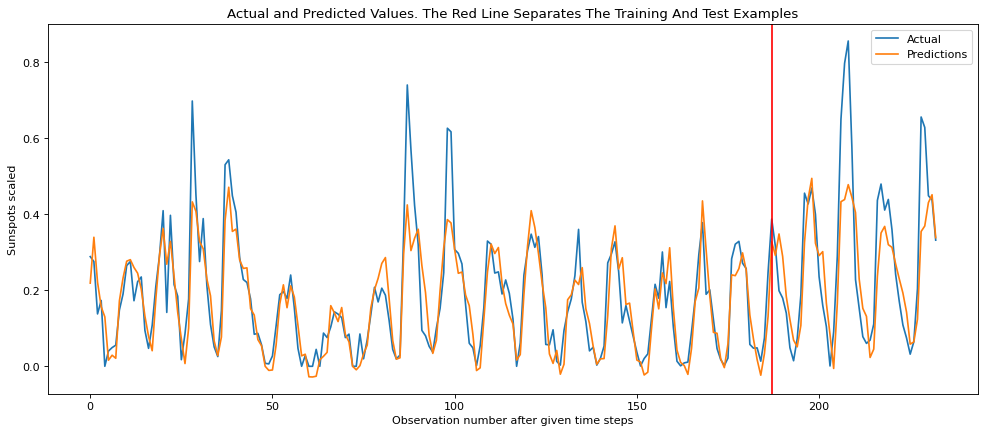

In [12]:
def plot_result(trainY, testY, train_predict, test_predict):
    actual = np.append(trainY, testY)
    predictions = np.append(train_predict, test_predict)
    rows = len(actual)
    plt.figure(figsize=(15, 6), dpi=80)
    plt.plot(range(rows), actual)
    plt.plot(range(rows), predictions)
    plt.axvline(x=len(trainY), color='r')
    plt.legend(['Actual', 'Predictions'])
    plt.xlabel("Observation number after given time steps")
    plt.ylabel('Sunspots scaled')
    plt.title("Actual and Predicted Values. The Red Line Separates The Training And Test Examples")
    plt.show()

plot_result(trainY, testY, train_predict, test_predict)